In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #


# Example parameters set up for environment
num_rows = 7
num_cols = 10
start_state = (0, 0)
goal_state = (5, 9)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10
cliff_reward = -100

# VI parameters
max_number_iterations = 200 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
# max_steps_in_env = 20 # used for episodic evaluation
max_steps_in_env = 100

Environment creation

In [5]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
# env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
#                         step_reward=step_reward, goal_reward=goal_reward,
#                         slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
# s = env.reset() # prepared clean environment

# Create the enhanced environment
from helpers.CustomSlipperyGridWorld import CustomSlipperyGridWorld

env = CustomSlipperyGridWorld(
    rows=num_rows,
    cols=num_cols,
    start=start_state,
    goal=goal_state,
    slip_prob=slip_prob,
    step_reward=step_reward,
    goal_reward=goal_reward,
    cliff_reward=cliff_reward,
    max_steps=max_steps_in_env,
    seed=random_seed
)
s = env.reset()

print(f"Environment created: {env.rows}x{env.cols}")
print(f"Walls: {len(env.walls)} cells")
print(f"Cliff cells: {len(env.cliff_states)}")

Environment created: 7x10
Walls: 8 cells
Cliff cells: 10


In [6]:
num_states = env.num_states
V = np.zeros(num_states)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration

# Pseudokod:
# initialization V(x) for all x \in X
# Repeat:
#     Delta <- 0;
#     for x in X:
#         V <- V(x);
#         V(x) <- \max_a \sum_{y,r} p(y,r|x,a)[r + gamma*V(y)];
#         Delta <- max(Delta, abs(V - V(x)));
#     end;
# until Delta < theta;

for k in range(max_number_iterations):
    delta = 0
    
    for x in range(num_states):
        if env.is_terminal_state(x):
            continue
        
        v = V[x]
        
        max_action_value = float('-inf')
        for a in ACTIONS:
            transitions = env.get_transition_distribution(x, a)
            
            action_value = 0
            for prob, y in transitions:
                r = env.reward(x, a, y)
                action_value += prob * (r + gamma * V[y])

            max_action_value = max(max_action_value, action_value)
        
        V[x] = max_action_value
        delta = max(delta, abs(v - V[x])) 
    
    if k == max_number_iterations - 1:
        print("Osiągnięto maksymalną liczbę iteracji")
        break

    if delta < threshold:  
        print(f"Zbieżność po {k+1} iteracjach")
        break


Zbieżność po 31 iteracjach


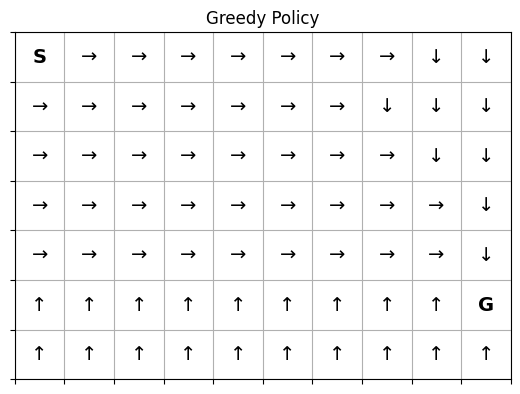

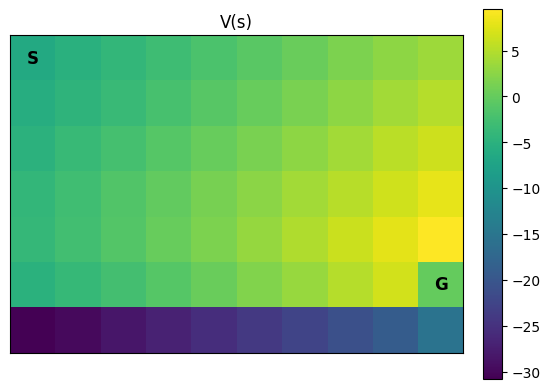

{'avg_return': -7.3, 'std_return': 5.866, 'success_rate': 1.0, 'avg_steps': 18.3}


In [7]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

Zaimplementować:
- algorytm Q-learning
- eksplorację epsilon-greedy
- wyznaczanie polityki zachłannej na podstawie wartości Q

In [8]:
# pseudokod:
# init Q(x,a);
# Q(terminalState, _) = 0;
# For each episode:
#   init X;
#   For each step of episode:
#     choose A from X using policy derived from Q (eps-greedy);
#     take action A, observe R and X';
#     Q(X,A) <- Q(X,A) + alpha*[R + gamma*max_a(Q(X',a)) - Q(X,A)];
#     X <- X';
#     if(X is terminal):
#       break;

In [9]:
num_episodes = 10000
alpha = 0.3
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95

np.random.seed = random_seed

def epsilon_greedy(Q, state, epsilon):
    if np.random.random() < epsilon:
        return np.random.choice(ACTIONS)
    else:
        return int(np.argmax(Q[state]))

# ----- Q-learning -----

# init Q(x,a);
Q = np.zeros((num_states, len(ACTIONS)))

# Q(terminalState, _) = 0;
goal_state_int = env.row_column_to_state(*goal_state)
Q[goal_state_int, :] = 0.0

for episode in range(num_episodes):
    # init X;
    X = env.reset()
    done = False

    while not done:
        # choose A from X using policy derived from Q (eps-greedy);
        A = epsilon_greedy(Q, X, epsilon)

        # take action A, observe R and X';
        X_next, R, done, info = env.step(A)

        # Q(X,A) <- Q(X,A) + alpha*[R + gamma*max_a(Q(X',a)) - Q(X,A)];
        max_a_Q = 0.0 if env.is_terminal_state(X_next) else np.max(Q[X_next])
        Q[X, A] += alpha * (R + gamma * max_a_Q - Q[X, A])

        # X <- X'
        X = X_next  

        if env.is_terminal_state(X):
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# fix na gradient
# Q[goal_state_int, :] = env.goal_reward

print(f"Trening zakończony. Końcowe epsilon: {epsilon:.4f}")

Trening zakończony. Końcowe epsilon: 0.0500


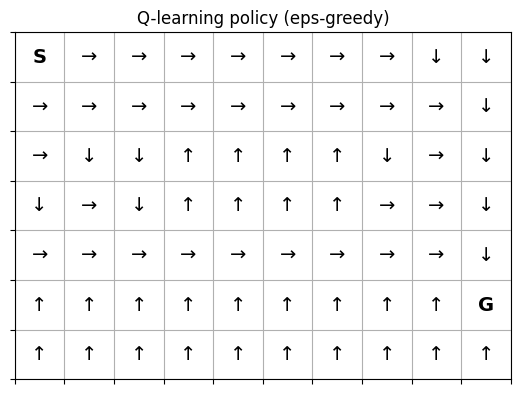

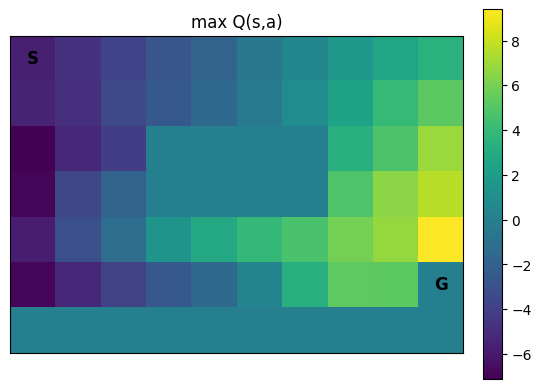

{'avg_return': -6.56, 'std_return': 2.3846, 'success_rate': 1.0, 'avg_steps': 17.56}


In [10]:
policy_plot_name = "policy_Q.png"
value_plot_name = "value_Q.png"
gif_name = "episode_Q.gif"
n_val_episodes = 50

pi_Q = np.argmax(Q, axis=1)
value = np.max(Q, axis=1)

plot_policy(env, pi_Q, filename=policy_plot_name, title="Q-learning policy (eps-greedy)")
plot_value_heatmap(env, value, filename=value_plot_name, title="max Q(s,a)")
metrics_Q = evaluate(env, Q=Q, n_episodes=n_val_episodes, seed=random_seed)
print(metrics_Q)
run_to_gif(env, Q=Q, gif_path=gif_name, fps=6)

SARSA

In [11]:
num_episodes = 10000
alpha = 0.3
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95

Q_sarsa = np.zeros((num_states, len(ACTIONS)))

for episode in range(num_episodes):
    X = env.reset()
    A = epsilon_greedy(Q_sarsa, X, epsilon)
    done = False

    while not done:
        X_next, R, done, info = env.step(A)

        # agent wybiera A' przed aktualizacją Q 
        A_next = epsilon_greedy(Q_sarsa, X_next, epsilon)

        # aktualizacja: Q(X', A'), nie max_{A'} Q(X', A')
        q_next = 0.0 if env.is_terminal_state(X_next) else Q_sarsa[X_next, A_next]
        Q_sarsa[X, A] += alpha * (R + gamma * q_next - Q_sarsa[X, A])

        X, A = X_next, A_next

        if env.is_terminal_state(X):
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

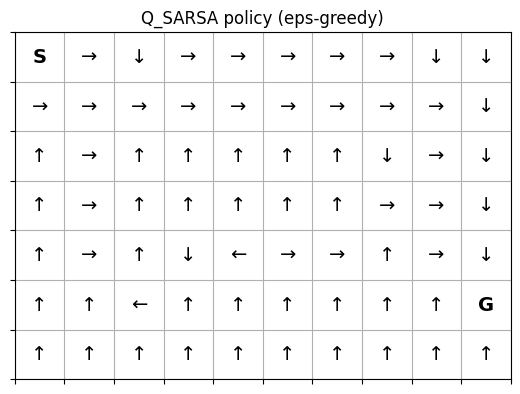

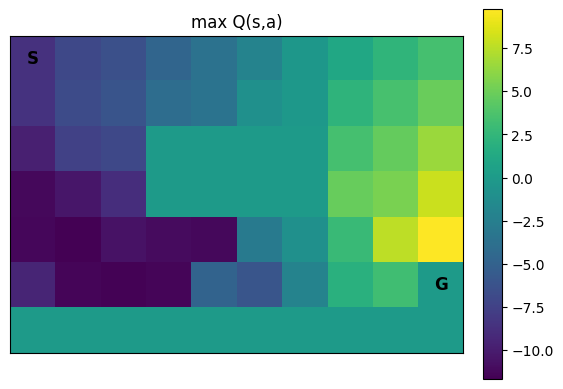

{'avg_return': -7.54, 'std_return': 3.0738, 'success_rate': 1.0, 'avg_steps': 18.54}


In [12]:
Q = Q_sarsa

policy_plot_name = "policy_Q_SARSA.png"
value_plot_name = "value_Q_SARSA.png"
gif_name = "episode_Q_SARSA.gif"
n_val_episodes = 50

pi_Q = np.argmax(Q, axis=1)
value = np.max(Q, axis=1)

plot_policy(env, pi_Q, filename=policy_plot_name, title="Q_SARSA policy (eps-greedy)")
plot_value_heatmap(env, value, filename=value_plot_name, title="max Q(s,a)")
metrics_Q = evaluate(env, Q=Q, n_episodes=n_val_episodes, seed=random_seed)
print(metrics_Q)
run_to_gif(env, Q=Q, gif_path=gif_name, fps=6)

Dyna-Q

In [13]:
num_episodes = 10000
alpha = 0.3
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95
n_planning = 50  

Q_dyna = np.zeros((num_states, len(ACTIONS)))

Model = {}

for episode in range(num_episodes):
    X = env.reset()
    done = False

    while not done:
        A = epsilon_greedy(Q_dyna, X, epsilon)

        X_next, R, done, info = env.step(A)

        max_a_Q = 0.0 if env.is_terminal_state(X_next) else np.max(Q_dyna[X_next])
        Q_dyna[X, A] += alpha * (R + gamma * max_a_Q - Q_dyna[X, A])

        Model[(X, A)] = (R, X_next) 

        for _ in range(n_planning):
            if not Model: 
                break
            s_rand, a_rand = random.choice(list(Model.keys()))
            r_model, s_next_model = Model[(s_rand, a_rand)]

            max_a_Q_model = 0.0 if env.is_terminal_state(s_next_model) else np.max(Q_dyna[s_next_model])
            Q_dyna[s_rand, a_rand] += alpha * (r_model + gamma * max_a_Q_model - Q_dyna[s_rand, a_rand])

        X = X_next

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print(f"Dyna-Q training finished. Final epsilon: {epsilon:.4f}, Planning steps per real step: {n_planning}")

Dyna-Q training finished. Final epsilon: 0.0500, Planning steps per real step: 50


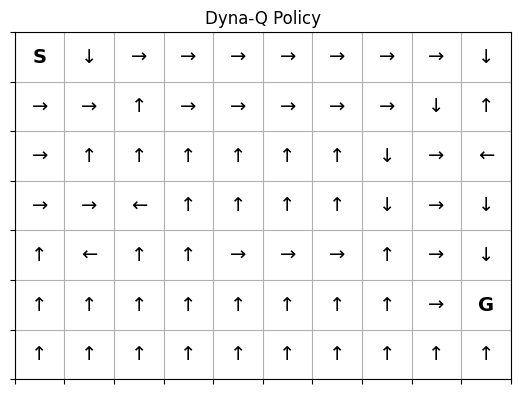

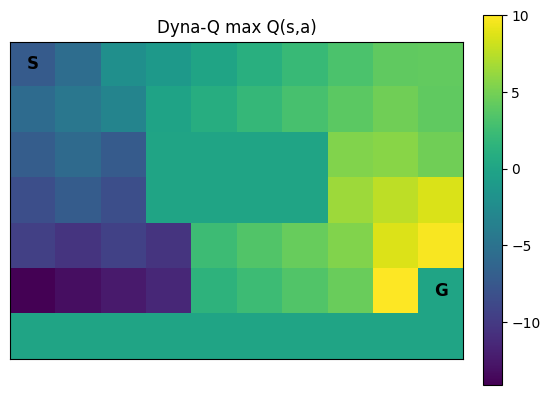

Dyna-Q Evaluation: {'avg_return': -37.26, 'std_return': 26.7079, 'success_rate': 0.92, 'avg_steps': 47.38}


In [14]:
policy_plot_name = "policy_Q_DynaQ.png"
value_plot_name = "value_Q_DynaQ.png"
gif_name = "episode_Q_DynaQ.gif"
n_val_episodes = 50

# Greedy policy from Q
pi_dyna = np.argmax(Q_dyna, axis=1)
value_dyna = np.max(Q_dyna, axis=1)

plot_policy(env, pi_dyna, filename=policy_plot_name, title="Dyna-Q Policy")
plot_value_heatmap(env, value_dyna, filename=value_plot_name, title="Dyna-Q max Q(s,a)")

# Evaluate
metrics_dyna = evaluate(env, Q=Q_dyna, n_episodes=n_val_episodes, seed=random_seed)
print("Dyna-Q Evaluation:", metrics_dyna)

# Generate GIF
run_to_gif(env, Q=Q_dyna, gif_path=gif_name, fps=6)